# Mercedes Stock Price Prediction

## 1. Introduction

This project aims to analyze and predict Mercedes-Benz stock prices using machine learning models.

We perform exploratory data analysis (EDA), feature engineering, and apply multiple models including neural networks to evaluate performance.

## 2. Importing the require libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import layers, Sequential

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 3. Data Exploration (EDA)

In [ ]:
df = pd.read_excel("data/mercedes_stock.xlsx")
df

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
0,1996-10-30,37.848667,37.878437,37.521210,37.550976,9.887261,1640521,1996,10,30,NaN,0.357227,NaN,NaN
1,1996-10-31,37.635983,38.057022,37.635983,38.052780,10.019385,1908031,1996,10,31,0.013363,0.421039,NaN,NaN
2,1996-11-01,38.273941,38.614124,38.082554,38.231346,10.066402,2423211,1996,11,1,0.004693,0.531570,NaN,NaN
3,1996-11-04,38.273941,38.609882,38.273941,38.529037,10.144786,1284644,1996,11,4,0.007787,0.335941,NaN,NaN
4,1996-11-05,38.694889,39.251991,38.507828,39.251991,10.335141,2105206,1996,11,5,0.018764,0.744163,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7506,2026-02-19,59.060001,59.340000,57.930000,58.750000,58.750000,2098591,2026,2,19,-0.010943,1.410000,59.3754,54.767225
7507,2026-02-20,58.389999,60.029999,58.290001,59.240002,59.240002,2979441,2026,2,20,0.008340,1.739998,59.3282,54.808075
7508,2026-02-23,59.270000,59.509998,58.299999,58.299999,58.299999,1960011,2026,2,23,-0.015868,1.209999,59.2642,54.835275
7509,2026-02-24,58.450001,59.360001,58.349998,58.930000,58.930000,1982969,2026,2,24,0.010806,1.010003,59.2212,54.860225


In [29]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
0,1996-10-30,37.848667,37.878437,37.521210,37.550976,9.887261,1640521,1996,10,30,NaN,0.357227,NaN,NaN
1,1996-10-31,37.635983,38.057022,37.635983,38.052780,10.019385,1908031,1996,10,31,0.013363,0.421039,NaN,NaN
2,1996-11-01,38.273941,38.614124,38.082554,38.231346,10.066402,2423211,1996,11,1,0.004693,0.531570,NaN,NaN
3,1996-11-04,38.273941,38.609882,38.273941,38.529037,10.144786,1284644,1996,11,4,0.007787,0.335941,NaN,NaN
4,1996-11-05,38.694889,39.251991,38.507828,39.251991,10.335141,2105206,1996,11,5,0.018764,0.744163,NaN,NaN


In [30]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
7506,2026-02-19,59.060001,59.340000,57.930000,58.750000,58.750000,2098591,2026,2,19,-0.010943,1.410000,59.3754,54.767225
7507,2026-02-20,58.389999,60.029999,58.290001,59.240002,59.240002,2979441,2026,2,20,0.008340,1.739998,59.3282,54.808075
7508,2026-02-23,59.270000,59.509998,58.299999,58.299999,58.299999,1960011,2026,2,23,-0.015868,1.209999,59.2642,54.835275
7509,2026-02-24,58.450001,59.360001,58.349998,58.930000,58.930000,1982969,2026,2,24,0.010806,1.010003,59.2212,54.860225
7510,2026-02-25,58.790001,59.000000,58.209999,58.990002,58.990002,1548145,2026,2,25,0.001018,0.790001,59.1862,54.885475


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7511 entries, 0 to 7510
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          7511 non-null   datetime64[ns]
 1   Open          7511 non-null   float64       
 2   High          7511 non-null   float64       
 3   Low           7511 non-null   float64       
 4   Close         7511 non-null   float64       
 5   Adj Close     7511 non-null   float64       
 6   Volume        7511 non-null   int64         
 7   Year          7511 non-null   int64         
 8   Month         7511 non-null   int64         
 9   Day           7511 non-null   int64         
 10  Daily_Return  7510 non-null   float64       
 11  Volatility    7511 non-null   float64       
 12  MA50          7462 non-null   float64       
 13  MA200         7312 non-null   float64       
dtypes: datetime64[ns](1), float64(9), int64(4)
memory usage: 821.6 KB


In [32]:
df.shape

(7511, 14)

In [33]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
count,7511,7511.000000,7511.000000,7511.000000,7511.000000,7511.000000,7.511000e+03,7511.000000,7511.000000,7511.000000,7510.000000,7511.000000,7462.000000,7312.000000
mean,2011-05-28 12:57:48.193316608,46.944158,47.513845,46.335167,46.922789,24.420731,5.469589e+06,2010.906005,6.510052,15.725869,0.000289,1.178678,46.902947,46.767496
min,1996-10-30 00:00:00,14.688660,15.108692,14.306056,14.505675,5.894059,0.000000e+00,1996.000000,1.000000,1.000000,-0.188521,0.000000,17.604018,20.246209
25%,2004-01-10 12:00:00,34.534153,34.933392,33.997677,34.482170,12.959133,2.922422e+06,2004.000000,3.000000,8.000000,-0.010210,0.715304,34.600985,34.517109
50%,2011-05-12 00:00:00,46.943829,47.492779,46.378239,46.952145,18.220886,4.604369e+06,2011.000000,7.000000,16.000000,0.000000,1.031364,46.794029,45.974716
75%,2018-10-01 12:00:00,57.837927,58.389004,57.136365,57.785747,32.315592,6.842950e+06,2018.000000,10.000000,23.000000,0.010559,1.488827,57.928073,57.119813
max,2026-02-25 00:00:00,85.521103,92.282379,84.542969,85.052834,65.410294,7.396760e+07,2026.000000,12.000000,31.000000,0.272767,8.079590,79.259742,70.276539
std,NaN,14.638879,14.745941,14.532735,14.626208,14.987799,4.100571e+06,8.489169,3.453225,8.742968,0.021443,0.703373,14.407436,13.800460


In [34]:
df.isnull().sum()

Date              0
Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
Year              0
Month             0
Day               0
Daily_Return      1
Volatility        0
MA50             49
MA200           199
dtype: int64

In [35]:
df = df.sort_values("Date")

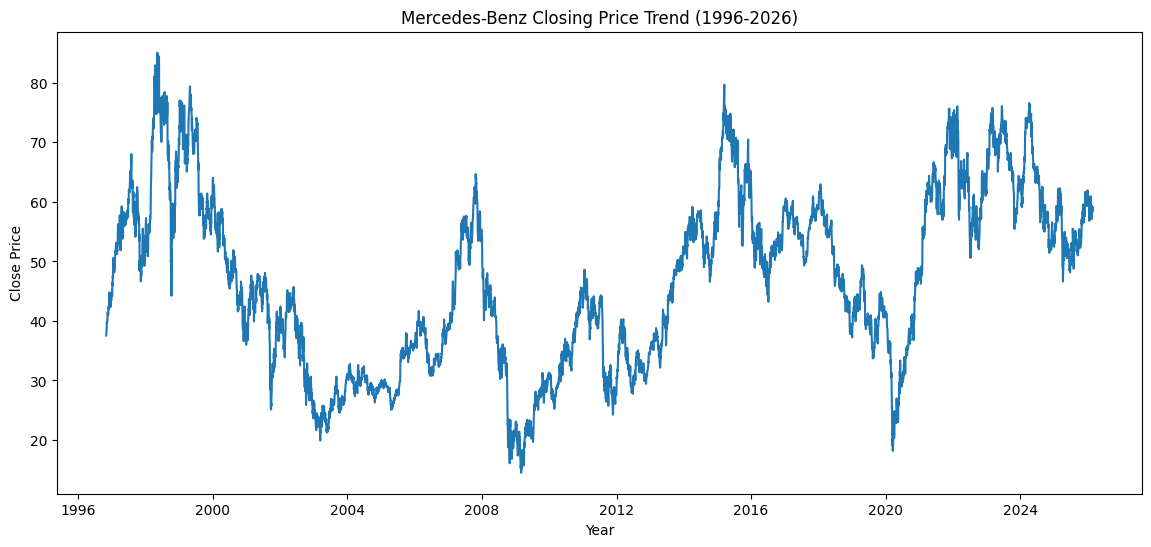

In [36]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"])

plt.title("Mercedes-Benz Closing Price Trend (1996-2026)")
plt.xlabel("Year")
plt.ylabel("Close Price")

plt.show()

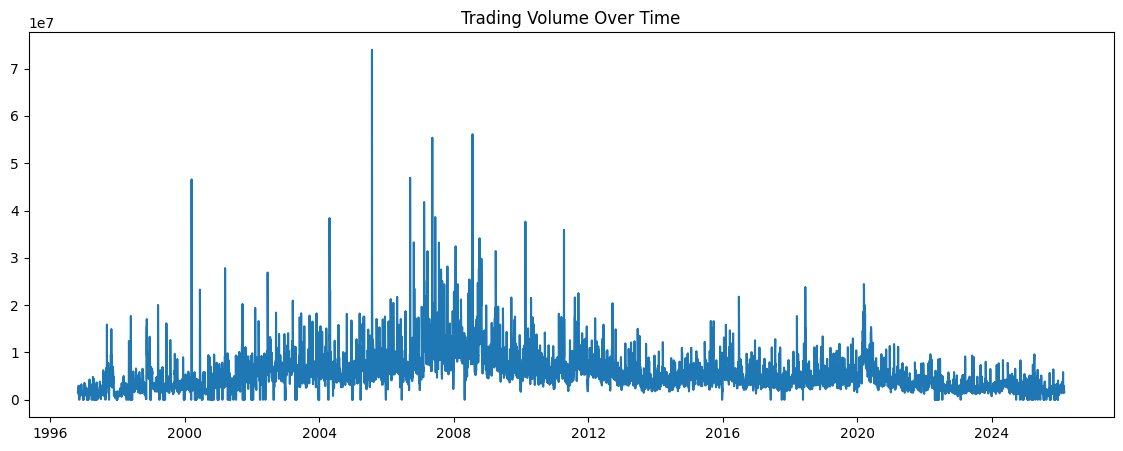

In [37]:
plt.figure(figsize=(14,5))

plt.plot(df["Date"], df["Volume"])

plt.title("Trading Volume Over Time")

plt.show()

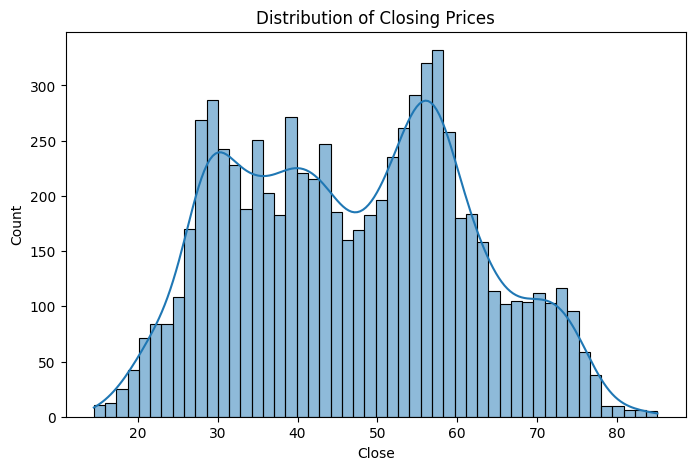

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(df["Close"], bins=50, kde=True)

plt.title("Distribution of Closing Prices")

plt.show()

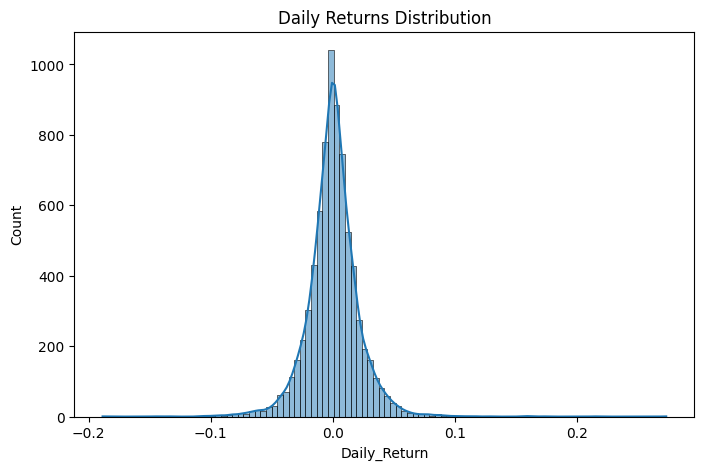

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(df["Daily_Return"], bins=100, kde=True)

plt.title("Daily Returns Distribution")

plt.show()

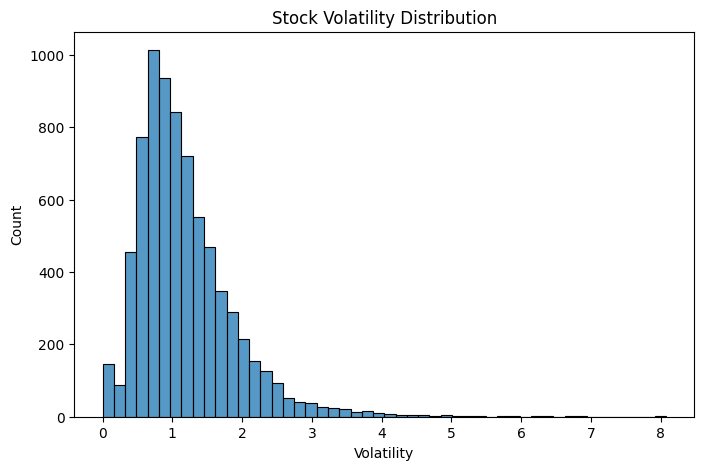

In [40]:
plt.figure(figsize=(8,5))

sns.histplot(df["Volatility"], bins=50)

plt.title("Stock Volatility Distribution")

plt.show()

In [41]:
monthly_avg = df.groupby("Month")["Close"].mean()

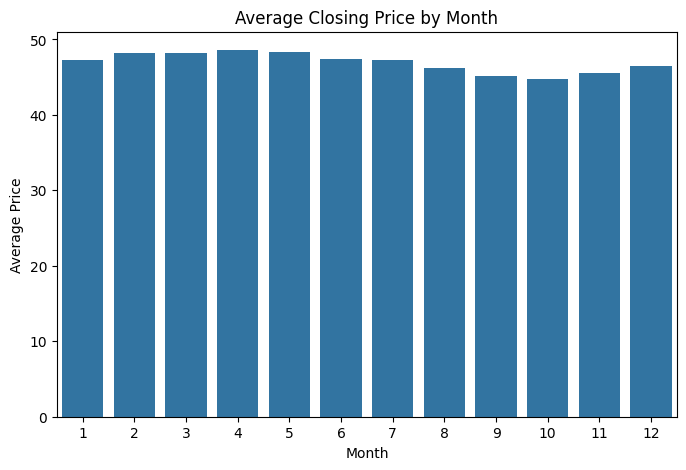

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(x=monthly_avg.index, y=monthly_avg.values)

plt.title("Average Closing Price by Month")

plt.xlabel("Month")
plt.ylabel("Average Price")

plt.show()

In [43]:
yearly_avg = df.groupby("Year")["Close"].mean()

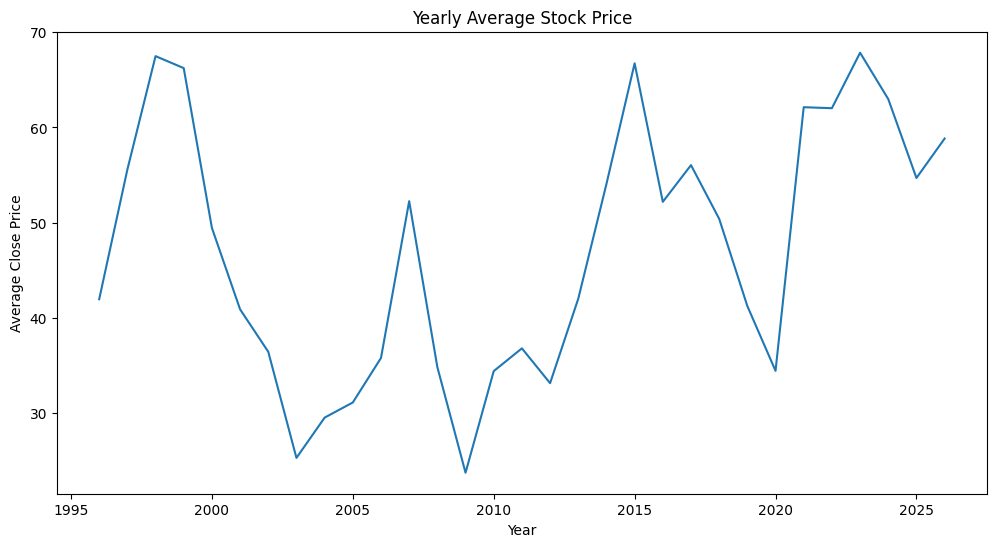

In [44]:
plt.figure(figsize=(12,6))

plt.plot(yearly_avg.index, yearly_avg.values)

plt.title("Yearly Average Stock Price")

plt.xlabel("Year")
plt.ylabel("Average Close Price")

plt.show()

In [45]:
corr = df[["Open","High","Low","Close","Volume"]].corr()

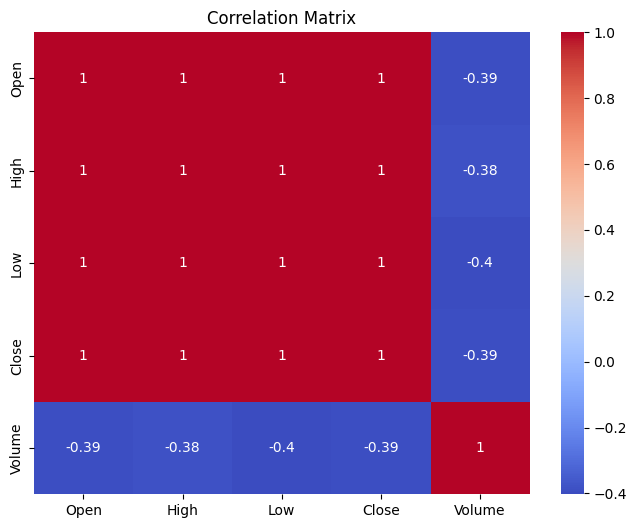

In [46]:
plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

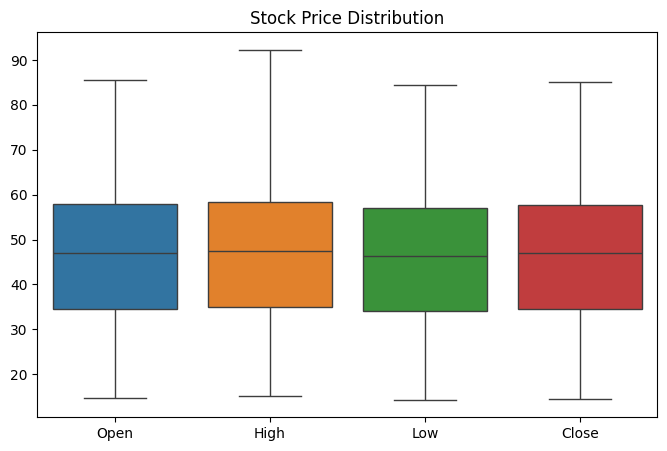

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["Open","High","Low","Close"]])

plt.title("Stock Price Distribution")

plt.show()

## 4. Feature Engineering

In [48]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [49]:
df["Daily_Return"] = df["Close"].pct_change()

In [50]:
df["Volatility"] = df["High"] - df["Low"]

In [51]:
df["MA50"] = df["Close"].rolling(50).mean()

In [52]:
df["MA200"] = df["Close"].rolling(200).mean()

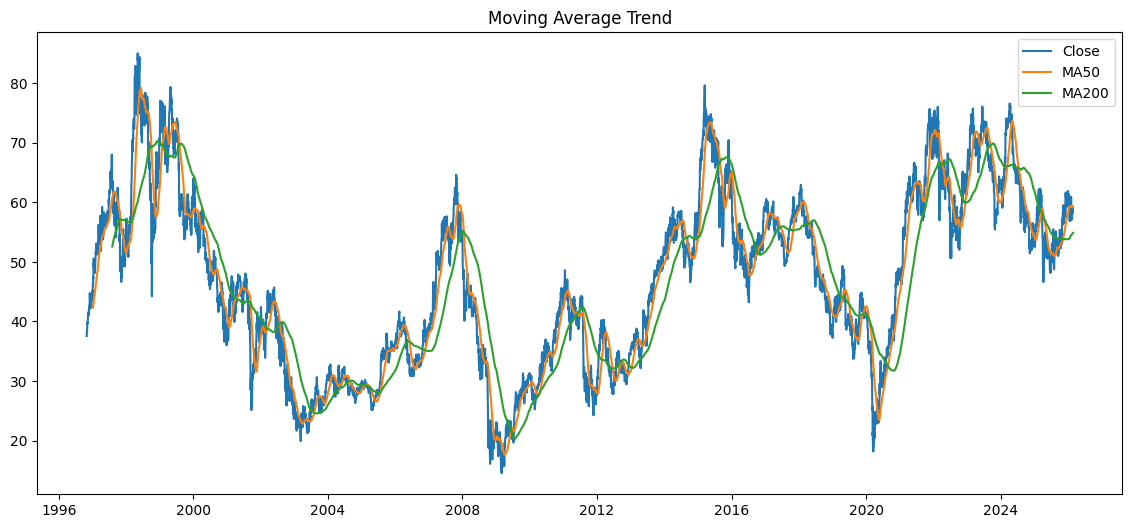

In [53]:
plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.plot(df["Date"], df["MA200"], label="MA200")

plt.legend()

plt.title("Moving Average Trend")

plt.show()

In [54]:
df.sort_values("Volume", ascending=False).head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
2281,2005-07-28,30.358782,33.602596,30.283924,32.845707,11.890225,73967595,2005,7,28,0.086980,3.318672,28.229508,28.221150
3043,2008-07-24,36.056252,36.430538,31.323608,31.997326,13.001400,56110996,2008,7,24,-0.096100,5.106930,36.309436,46.318061
2739,2007-05-14,52.233742,54.346378,50.794819,51.318817,19.899010,55382111,2007,5,14,0.017984,3.551559,48.466923,39.850476
2574,2006-09-15,34.617329,34.633965,31.639673,32.587864,12.263064,46920409,2006,9,15,-0.055676,2.994292,33.180069,35.663335
882,2000-03-17,58.629879,58.837814,55.851841,57.423843,15.630005,46575930,2000,3,17,-0.011596,2.985973,56.351889,60.105731
2679,2007-02-14,41.213085,43.317410,41.213085,42.834995,16.119141,41784620,2007,2,14,0.045898,2.104325,39.252325,35.290088
2762,2007-06-15,56.675274,57.939529,56.409115,57.373940,22.246902,38618038,2007,6,15,0.013518,1.530414,52.441178,42.321265
1952,2004-04-23,32.687675,32.737579,31.731165,31.731165,10.887870,38392720,2004,4,23,0.057079,1.006414,29.174041,28.423763
3441,2010-02-18,27.485086,27.742935,24.890041,26.195887,10.968528,37633309,2010,2,18,-0.046761,2.852894,29.262456,26.616646
2680,2007-02-15,44.831188,45.687889,44.124203,44.431950,16.720087,36496492,2007,2,15,0.037282,1.563686,39.409858,35.331093


In [55]:
df.sort_values("Daily_Return", ascending=False).head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
6002,2020-03-24,20.544163,24.353565,20.381971,24.353565,16.931505,16260714,2020,3,24,0.272767,3.971594,31.849190,37.797599
3112,2008-10-29,19.084446,19.882923,17.974062,19.546064,7.942109,26562040,2008,10,29,0.214470,1.908861,28.065072,36.951399
3130,2008-11-24,17.217173,20.003527,16.759710,19.737368,8.019839,14586887,2008,11,24,0.172431,3.243817,23.157429,34.900456
3100,2008-10-13,21.542259,21.874958,20.174034,21.791782,8.854606,24699512,2008,10,13,0.161090,1.700924,31.437059,38.620030
508,1998-10-12,50.393997,53.881184,49.756130,53.796085,14.164634,3115902,1998,10,12,0.158424,4.125054,66.303179,69.388689
3218,2009-04-02,16.801298,18.743429,16.780504,18.543810,7.534863,31430004,2009,4,2,0.156380,1.962925,17.618324,24.455080
3201,2009-03-10,15.794884,17.662157,15.774090,17.400158,7.070167,15099020,2009,3,10,0.127155,1.888067,18.876758,26.225413
6011,2020-04-06,21.583845,22.744135,21.413338,22.744135,15.812570,8107113,2020,4,6,0.115212,1.330797,29.082965,36.997125
6038,2020-05-18,23.804611,25.979631,23.796295,25.933886,18.030203,8870910,2020,5,18,0.113373,2.183336,23.561575,34.939465
3113,2008-10-30,20.619019,22.207657,20.053431,21.617117,8.783634,25280835,2008,10,30,0.105958,2.154226,27.836258,36.850633


In [56]:
df.sort_values("Daily_Return").head(10)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
5994,2020-03-12,24.436741,24.657152,20.864386,20.872702,14.511480,24436875,2020,3,12,-0.188521,3.792766,35.196142,38.576821
3095,2008-10-06,25.035599,25.339186,21.625435,22.623531,9.192568,28657425,2008,10,6,-0.145460,3.713751,32.464600,39.462799
5991,2020-03-09,26.782269,26.794744,24.994011,25.097979,17.449049,18649227,2020,3,9,-0.134395,1.800733,36.235660,38.810189
506,1998-10-08,48.799206,48.799206,43.844894,44.227673,11.645248,5252195,1998,10,8,-0.108061,4.954312,67.356562,69.454074
5996,2020-03-16,19.961939,20.248892,18.444000,19.063650,13.253759,17741977,2020,3,16,-0.106433,1.804892,34.375956,38.385686
1272,2001-09-14,31.814341,31.980690,28.503984,28.503984,8.532636,10846803,2001,9,14,-0.103818,3.476706,42.802223,43.176468
3102,2008-10-15,23.372103,23.530134,20.535845,21.101433,8.574099,17756385,2008,10,15,-0.100355,2.994289,31.017526,38.335115
3118,2008-11-06,21.874958,22.378164,20.564957,20.739622,8.427082,13717593,2008,11,6,-0.098029,1.813207,26.701921,36.356263
3043,2008-07-24,36.056252,36.430538,31.323608,31.997326,13.001400,56110996,2008,7,24,-0.096100,5.106930,36.309436,46.318061
3097,2008-10-08,21.159655,24.120676,19.471209,20.652288,8.391597,34129212,2008,10,8,-0.093796,4.649467,32.062034,39.137003


## 5. Data Preprocessing

In [57]:
df1= df.copy()

In [58]:
df1=df1.dropna(axis=0)

In [59]:
df1.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Year',
       'Month', 'Day', 'Daily_Return', 'Volatility', 'MA50', 'MA200'],
      dtype='object')

In [60]:
features= [ 'Open', 'High', 'Low', 'Adj Close', 'Volume', 'Year',
       'Month', 'Day', 'Daily_Return', 'Volatility', 'MA50', 'MA200']

In [61]:
X = df1[features]
y = df1['Close']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=0)

In [63]:
scaler = StandardScaler()

In [64]:
X_train_sc = scaler.fit_transform(X_train)
X_val_sc= scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [65]:
X_train= pd.DataFrame(X_train_sc, columns=features)
X_val= pd.DataFrame(X_val_sc, columns=features)
X_test= pd.DataFrame(X_test_sc, columns=features)

In [66]:
X_train

,Open,High,Low,Adj Close,Volume,Year,Month,Day,Daily_Return,Volatility,MA50,MA200
0,-0.756305,-0.701141,-0.727229,-0.890277,0.515962,-1.130401,0.717061,-0.649804,2.343515,0.320673,-0.676684,-0.503944
1,2.291577,2.234125,2.348558,-0.231412,-1.348128,-1.615844,-0.732148,-0.649804,-0.015232,-1.662950,1.334019,0.873228
2,-0.108195,-0.109013,-0.131956,-0.496927,3.118724,-0.402238,-1.601674,0.271375,-1.061881,0.436671,0.535510,0.603356
3,0.753701,0.790618,0.768033,0.334288,0.192937,0.447287,-1.601674,-0.764951,-0.442669,0.703475,0.535568,0.541987
4,0.866270,0.877311,0.806496,-0.625376,2.447324,-1.737205,0.717061,-0.649804,-1.184895,1.717670,1.026853,0.604439
...,...,...,...,...,...,...,...,...,...,...,...,...
5259,0.142160,0.148263,0.159167,-0.715146,-0.688520,-1.373123,0.427220,-0.880098,0.379610,-0.178136,0.079303,0.549107
5260,0.224861,0.192352,0.186920,-0.022912,-0.512287,0.204566,1.006903,1.422848,-0.706515,0.169871,0.031045,-0.433716
5261,1.403521,1.408210,1.409573,1.926220,-0.778433,1.418172,-1.601674,1.768291,0.277348,0.401162,1.238018,0.989099
5262,-0.741677,-0.694444,-0.736858,-0.665322,1.931135,-0.402238,0.427220,-0.419509,0.620249,0.657071,-0.876147,-0.164350


## 6. Machine Learning Models

In [67]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

In [68]:
results = {}
for name, model in [
    ("LinearRegression", LinearRegression()),
    ("RandomForest", RandomForestRegressor(n_estimators=100,random_state=42)),
    ("HistGradientBoosting", HistGradientBoostingRegressor())
]:
    results[name] = evaluate_model(model, X_train, y_train, X_test, y_test)

pd.DataFrame(results).T

,MAE,RMSE,R2
LinearRegression,0.239197,0.344102,0.999453
RandomForest,0.241520,0.338408,0.999471
HistGradientBoosting,0.243361,0.350469,0.999432


## 7. Neural Network Model

In [69]:
nn_reg_model= Sequential([
    layers.Dense(units=256, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=64, activation='relu'),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=8, activation='relu'),
    layers.Dense(units=4, activation='relu'),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-09 10:11:31.364376: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [70]:
nn_reg_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,865 (183.07 KB)

 Trainable params: 46,865 (183.07 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
nn_reg_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [72]:
history=nn_reg_model.fit(
    X_train_sc,y_train.values,
    validation_data=(X_val_sc,y_val.values),
    epochs=50,
    batch_size=32
)

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1049.5991 - mae: 25.6753 - val_loss: 49.6610 - val_mae: 5.5775
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 39.4245 - mae: 4.6979 - val_loss: 11.7418 - val_mae: 2.6456
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10.3109 - mae: 2.2464 - val_loss: 2.3772 - val_mae: 1.2157
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8151 - mae: 1.1087 - val_loss: 0.9160 - val_mae: 0.7302
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0163 - mae: 0.7408 - val_loss: 0.6553 - val_mae: 0.6209
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8394 - mae: 0.6572 - val_loss: 0.6327 - val_mae: 0.5981
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6680 - mae: 0.6068 - val_loss: 0.4901 - val_mae: 0.5294
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5411 - mae: 0.5539 - val_loss: 0.4993 - val_mae: 0.5323
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/s

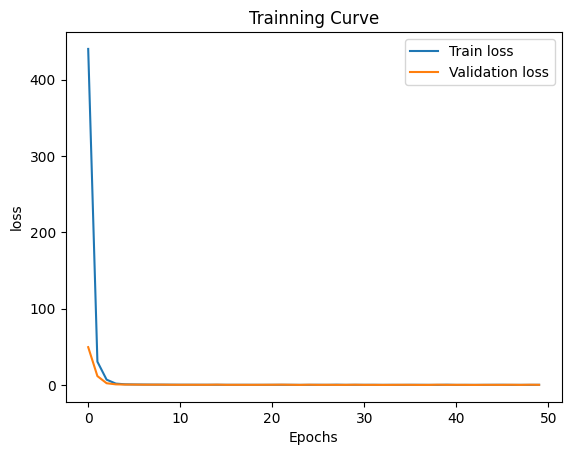

In [73]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Trainning Curve')
plt.legend()
plt.show()

## 8. Results Comparison

In [74]:
y_pred_nn = nn_reg_model.predict(X_test_sc).flatten()

mae = mean_absolute_error(y_test, y_pred_nn)
mse = mean_squared_error(y_test, y_pred_nn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_nn)

results["NeuralNetwork"] = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

pd.DataFrame(results).T

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,MAE,RMSE,R2
LinearRegression,0.239197,0.344102,0.999453
RandomForest,0.241520,0.338408,0.999471
HistGradientBoosting,0.243361,0.350469,0.999432
NeuralNetwork,0.448998,0.565622,0.998521


<Axes: xlabel='index', ylabel='Score'>

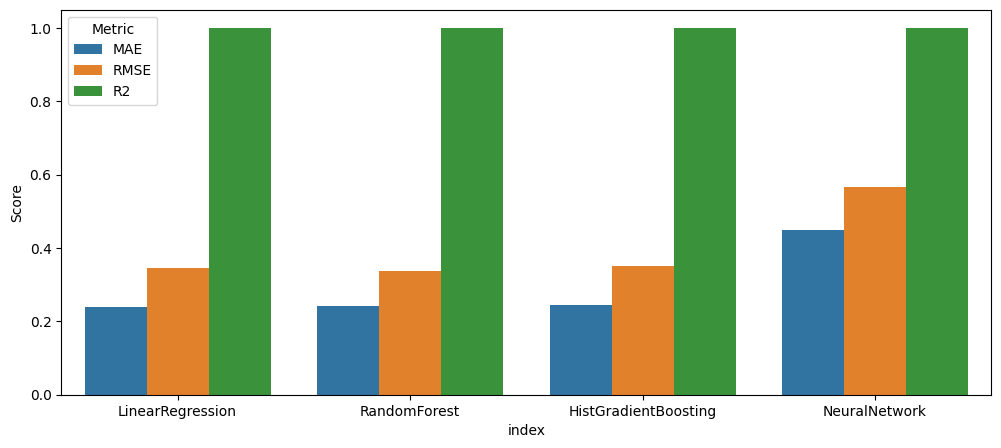

In [75]:
plt.figure(figsize=(12,5))
df_results = pd.DataFrame(results).T.reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
sns.barplot(x="index", y="Score", hue="Metric", data=df_results)

## 9. Conclusion

In this project, we analyzed and predicted Mercedes-Benz stock prices using multiple machine learning models, including Linear Regression, Random Forest, Gradient Boosting, and a Neural Network.

The results show that all machine learning models achieved very similar performance, with minimal differences in MAE, RMSE, and R² scores. This indicates that the models are capturing similar patterns in the data.

The Neural Network performed slightly worse compared to the other models, suggesting that traditional machine learning models may be more suitable for this type of tabular financial data.

However, the extremely high R² scores (~0.999) across all models suggest potential data leakage, as some engineered features (such as moving averages and daily returns) are derived from the target variable (Close price).

Overall, this project highlights the importance of proper feature engineering, model comparison, and critical evaluation of model performance.